# **Experiment Notebook**



In [1]:
# Do not modify this code
!pip install -q utstd

from utstd.ipyrenders import *

In [2]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

In [3]:
# <Student to fill this section>
import pandas as pd 
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import joblib

This cell imports all the required libraries and modules for data analysis, feature engineering, modeling, and evaluation in this experiment.

---
## B. Business Understanding

In [8]:
# <Student to fill this section>

business_use_case_description = """
# Hypothesis for the project

# Null Hypothesis (H0): Using an ensemble of models does not reduce overfitting or improve 
# the generalization of the model. The model's performance (measured by AUROC and recall) 
# will remain the same or worsen compared to single models.

# Alternative Hypothesis (H1): Using an ensemble of models reduces overfitting and improves the 
# generalization of the model. The model's performance (measured by AUROC and recall) will improve or 
# remain stable compared to single models.

Null Hypothesis (H0): Reducing the number of features for training the model does not decrease noise or 
improve the model’s ability to capture the signal. Model performance (measured by AUROC and recall) will 
remain the same or worsen after feature reduction.

Alternative Hypothesis (H1): Reducing the number of features for training the model does decrease noise and 
allows the model to better capture the signal. Model performance (measured by AUROC and recall) will improve
or remain stable after feature reduction.

Business Use Case Description:
NBA teams invest significant resources in scouting and evaluating college players to identify those most 
likely to succeed at the professional level. However, the draft process is highly competitive, and teams must 
make decisions with limited information and time. By leveraging advanced machine learning techniques, we aim 
to build a predictive model that estimates the probability of each player being drafted.

This probability score enables teams, scouts, and analysts to:
- Prioritize Scouting Efforts: Focus attention and resources on players with the highest likelihood of being 
drafted, improving efficiency.
- Support Data-Driven Decision Making: Combine traditional scouting with objective, data-driven insights to 
reduce bias and improve draft outcomes.
- Benchmark and Compare Players: Quantitatively compare players across teams and conferences, identifying 
hidden talent that may be overlooked by conventional methods.
- Strategic Planning: Inform roster planning, negotiations, and long-term team-building strategies by 
understanding the draft landscape.

Why Probability (Not Just Yes/No)?
Predicting the probability (rather than a simple yes/no) provides richer information for decision-makers. 
Teams can set their own thresholds for action, assess risk, and better understand the uncertainty in each 
prediction. This approach supports nuanced, flexible strategies tailored to each team's needs and risk 
tolerance.

Ultimately, this project aims to enhance the draft process, giving NBA teams a competitive edge in 
identifying and selecting future stars, while also providing valuable feedback to players, coaches, and 
other stakeholders in the basketball ecosystem.
"""


In [9]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [10]:
# <Student to fill this section>


business_objectives = """
The primary business objective of this project is to enable NBA teams and stakeholders to make more informed, data-driven decisions during the player draft process by predicting the probability that a college basketball player will be drafted.

Expanded Business Objectives:
- Enhance Scouting Efficiency: By providing a probability score for each player, teams can prioritize 
their scouting resources on those with the highest likelihood of being drafted, reducing time and costs 
associated with manual evaluation.
- Support Strategic Decision-Making: Data-driven predictions help teams supplement traditional scouting 
with objective analytics, reducing human bias and improving the overall quality of draft selections.
- Identify Hidden Talent: The model can uncover high-potential players who may be overlooked by 
conventional scouting, giving teams a competitive edge in discovering undervalued talent.
- Benchmark Player Performance: Quantitative draft probabilities allow teams to compare players across 
different schools, conferences, and backgrounds on a level playing field.
- Risk Management: By predicting probabilities (rather than binary outcomes), teams can assess the 
uncertainty and risk associated with each player, enabling more nuanced and flexible draft strategies.
- Stakeholder Value: The insights generated can also benefit college players (to understand their draft 
prospects), sports analysts, and fans, fostering greater engagement and transparency in the draft process.

Ultimately, the objective is to improve the effectiveness and fairness of the NBA draft, maximizing the value 
of team investments and supporting the long-term success of both players and organizations.
"""


In [11]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [12]:
# <Student to fill this section>
stakeholders_expectations_explanations = """
How will the results be used?
The results of the predictive model will be used to estimate the probability that a college basketball player 
will be drafted into the NBA. These probabilities will help stakeholders make more informed, data-driven 
decisions regarding player evaluation, scouting, and draft strategy.

Who will be the users of your predictions? Who will be impacted by your predictions?
Primary users:
- NBA Teams & Scouts: To prioritize scouting resources, identify high-potential players, and support draft 
decisions.
- College Players & Coaches: To understand draft prospects and adjust training or exposure strategies 
accordingly.
- Sports Analysts & Commentators: To provide data-driven insights and narratives during draft coverage 
and analysis.
- Data Scientists & Researchers: To benchmark predictive modeling approaches in sports analytics.

Impacted stakeholders:
- College Players: Their perceived draft value and future opportunities may be influenced by model predictions.
- NBA Teams: Improved decision-making can lead to better team performance and return on investment.
- Fans: Enhanced engagement through transparent, data-driven draft discussions.
- The broader basketball ecosystem: Increased fairness and efficiency in the draft process.

Quantitative Expectations:
- The model is expected to predict the probability of a player being drafted with certainty of at least 
95% on the test set.
- The Area Under the ROC Curve (AUROC) should be at least 0.95, indicating strong discriminative ability 
between drafted and non-drafted players.
- The model should maintain high recall for the minority (drafted) class to minimize the risk of missing 
top talent.


Overall, the model aims to support fairer, more effective, and transparent draft outcomes, benefiting both 
organizations and individuals involved in the NBA draft process.
"""


In [13]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets


we are using the features_list from experiment 1

In [14]:
# <Student to fill this section>




X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv')
X_val = pd.read_csv('../data/processed/X_val.csv')
y_val = pd.read_csv('../data/processed/y_val.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv')
test=pd.read_csv('../data/processed/test_transformed.csv')


This cell loads the processed training, validation, and test datasets from CSV files to begin the experiment.

In [15]:
features_list= list(X_train.columns)

---
## D. Data transformation

### D.1 Data Transformation "Applying PCA"


Since LR, LDA are working best with less number of feature so we will reduce the features using PCA

In [16]:
from sklearn.decomposition import PCA
test_original = test.copy()  # Keep a copy of the original test DataFrame
# Perform PCA directly (example: 20 components)
pca = PCA(n_components=20, random_state=42)
X_train = pca.fit_transform(X_train)
X_val = pca.transform(X_val)
X_test = pca.transform(X_test)
test = pca.transform(test[features_list])

# Optionally, print explained variance
print("Explained variance ratio (train):", pca.explained_variance_ratio_)
print("Total explained variance (train):", pca.explained_variance_ratio_.sum())

Explained variance ratio (train): [0.39970344 0.10255934 0.08601474 0.04804158 0.03789892 0.03063408
 0.02677699 0.02429812 0.0227183  0.01849918 0.01812679 0.01664827
 0.01622257 0.01346884 0.01305735 0.01176746 0.01143094 0.00956904
 0.00892454 0.00841556]
Total explained variance (train): 0.9247760477729365


This cell applies Principal Component Analysis (PCA) to reduce the feature dimensionality of the training, validation, test, and submission datasets, retaining the top 20 principal components.

In [17]:
# <Student to fill this section>
data_transformation_1_explanations = """
Principal Component Analysis (PCA) was applied directly to the original features of all datasets (train, validation, test, 
and submission) without standard scaling. PCA reduced the dimensionality to 20 principal components, capturing about 79.7% of 
the total variance in the training data. This transformation helps remove redundant information and noise, allowing the model to 
focus on the most important patterns in the data. Standard scaling was not used because the features were already on a similar 
scale or scaling was not required for this context.
"""

In [18]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

---
## E. Save Datasets

> Do not change this code

In [19]:
# Do not modify this code
# Save training set
try:
  X_train.to_csv(at.folder_path / 'X_train.csv', index=False)
  y_train.to_csv(at.folder_path / 'y_train.csv', index=False)

  X_val.to_csv(at.folder_path / 'X_val.csv', index=False)
  y_val.to_csv(at.folder_path / 'y_val.csv', index=False)

  X_test.to_csv(at.folder_path / 'X_test.csv', index=False)
  y_test.to_csv(at.folder_path / 'y_test.csv', index=False)
except Exception as e:
  print(e)

'numpy.ndarray' object has no attribute 'to_csv'


---
## F. Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate


In [20]:
# <Student to fill this section>
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import recall_score

In [21]:
# <Student to fill this section>
performance_metrics_explanations = """
Provide some explanations on why you believe the performance metrics you chose is appropriate


AUROC is especially suitable for imbalanced datasets like this one, as it is insensitive to class 
distribution and provides a robust evaluation of model performance. It summarizes the trade-off between 
true positive rate and false positive rate, making it a reliable metric for binary classification problems 
where ranking predictions is important.

Recall is appropriate because it measures the model's ability to correctly identify all players who were actually drafted. In this context, missing a 
potential draftee (false negative) is more costly than a false positive, so maximizing recall helps ensure valuable players are not overlooked.


"""



In [22]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## G. Train Machine Learning Model

### G.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit


In [23]:
# <Student to fill this section>
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier


This cell imports the necessary components for building the ensemble model, including Logistic Regression, Linear Discriminant Analysis, XGBoost, and VotingClassifier.

In [24]:
# <Student to fill this section>
algorithm_selection_explanations = """
Provide some explanations on why you believe this algorithm is a good fit


The ensemble combines Logistic Regression, Linear Discriminant Analysis (LDA), and XGBoost, leveraging the
strengths of each algorithm. Logistic Regression provides a strong linear baseline and is interpretable. 
LDA is effective for dimensionality reduction and works well when class distributions are approximately 
normal. XGBoost is a powerful gradient boosting method that captures complex nonlinear relationships and 
handles feature interactions. By ensembling these diverse models with soft voting, we improve robustness 
and predictive performance, reducing the risk of overfitting to any single model's biases. 
This approach is especially suitable for structured tabular data and imbalanced classification tasks 
like this NBA draft prediction problem.

"""


In [25]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### G.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [26]:
# <Student to fill this section>

In [27]:
logreg_params = {
    'C': 0.1,                # Regularization strength (try values like 0.01, 0.1, 1, 10)
    'penalty': 'l2',         # Regularization type ('l1', 'l2', 'elasticnet', 'none')
    'solver': 'saga',       # Optimization algorithm ('liblinear', 'lbfgs', 'saga', etc.)
    'class_weight': 'balanced', # Handle class imbalance
    'max_iter': 200,         # Maximum number of iterations
    'random_state': 42       # For reproducibility
}


This cell defines the hyperparameters for the Logistic Regression model, including regularization, solver, and class weight settings.

In [28]:
lda_params = {
    'solver': 'lsqr',         # Options: 'svd', 'lsqr', 'eigen'
    'shrinkage': 0.9,      #auto, float between 0-1 # Only used if solver is 'lsqr' or 'eigen'
    'store_covariance': False,  #true , false
    'tol': 1e-4                #float, default=1e-4, lower mean high precision and computation time.

}

This cell defines the hyperparameters for the Linear Discriminant Analysis (LDA) model, including solver and shrinkage settings.

In [29]:

neg, pos = np.bincount(y_train.values.ravel().astype(int))

scale_pos_weight = neg / pos
xgb_params = {
    'n_estimators': 3000,           # Number of boosting rounds (trees)
    'max_depth': 5,                # Maximum tree depth for base learners
    'learning_rate': 0.3,          # Step size shrinkage (eta)
    'subsample': 0.05,              # Subsample ratio of the training instances
    'colsample_bytree': 0.6,       # Subsample ratio of columns when constructing each tree
    'random_state': 42,            # Random seed for reproducibility
    'use_label_encoder': False,    # Disable label encoder (recommended for sklearn API)
    'scale_pos_weight': scale_pos_weight,   # to address class imbalance
    'eval_metric': 'auc'       # Evaluation metric for validation data
}

This cell defines the hyperparameters for the XGBoost model, including settings to handle class imbalance and optimize model performance.

In [30]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
Explain why you are tuning these hyperparameters

- Tuning these hyperparameters allows us to optimize each model's performance for our specific dataset and 
problem. 
- For Logistic Regression, adjusting regularization strength (C), penalty type, and solver helps 
balance bias and variance, and handle class imbalance. 
- For LDA, tuning the solver and shrinkage improves 
class separation and model stability. 
- For XGBoost, parameters like n_estimators, max_depth, learning_rate, 
subsample, colsample_bytree, and scale_pos_weight control model complexity, learning speed, and address 
class imbalance. 

Careful tuning ensures each model contributes effectively to the ensemble, leading to 
better overall predictive performance.



"""


In [31]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### G.3 Fit Model

In [32]:
# <Student to fill this section>
# Instantiate models with provided parameters
logreg = LogisticRegression(**logreg_params)
lda = LinearDiscriminantAnalysis(**lda_params)
xgb = XGBClassifier(**xgb_params)


This cell instantiates the base models (Logistic Regression, LDA, and XGBoost) with the defined hyperparameters for use in the ensemble.

In [33]:
# Create the ensemble VotingClassifier (soft voting for probabilities)
ensemble = VotingClassifier(
    estimators=[
        ('logreg', logreg),
        ('lda', lda),
        ('xgb', xgb)
    ],
    voting='soft',  # Use 'soft' for probability averaging
    n_jobs=-1
)

This cell creates the ensemble VotingClassifier using soft voting, combining the predictions of Logistic Regression, LDA, and XGBoost.

In [34]:
# Fit ensemble on training data
ensemble.fit(X_train, y_train.values.ravel() if hasattr(y_train, 'values') else y_train)


VotingClassifier(estimators=[('logreg',
                              LogisticRegression(C=0.1, class_weight='balanced',
                                                 max_iter=200, random_state=42,
                                                 solver='saga')),
                             ('lda',
                              LinearDiscriminantAnalysis(shrinkage=0.9,
                                                         solver='lsqr')),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.6, device=None,
                                            early_stop...
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.3, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=5,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=3000, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=42, ...))],
                 n_jobs=-1, voting='soft')

This cell fits the ensemble VotingClassifier on the training data, training all base models simultaneously.

### G.4 Model Technical Performance

> Provide some explanations on model performance


In [35]:
# <Student to fill this section>
from sklearn.metrics import roc_auc_score, recall_score

# Training predictions
y_train_pred_proba = ensemble.predict_proba(X_train)[:, 1]
y_train_pred = ensemble.predict(X_train)
train_auroc = roc_auc_score(y_train, y_train_pred_proba)
train_recall = recall_score(y_train, y_train_pred)

# Validation predictions
y_val_pred_proba = ensemble.predict_proba(X_val)[:, 1]
y_val_pred = ensemble.predict(X_val)
val_auroc = roc_auc_score(y_val, y_val_pred_proba)
val_recall = recall_score(y_val, y_val_pred)

# Test predictions
y_test_pred_proba = ensemble.predict_proba(X_test)[:, 1]
y_test_pred = ensemble.predict(X_test)
test_auroc = roc_auc_score(y_test, y_test_pred_proba)
test_recall = recall_score(y_test, y_test_pred)

print(f"Train AUROC: {train_auroc:.4f}, Recall: {train_recall:.4f}")
print(f"Validation AUROC: {val_auroc:.4f}, Recall: {val_recall:.4f}")
print(f"Test AUROC: {test_auroc:.4f}, Recall: {test_recall:.4f}")

Train AUROC: 0.9878, Recall: 1.0000
Validation AUROC: 0.9840, Recall: 0.9474
Test AUROC: 0.9825, Recall: 0.9474


This cell predicts probabilities and calculates AUROC and recall for the train, validation, and test sets using the trained ensemble model, providing a comprehensive evaluation of model performance.

In [36]:
# Assume you still have the original test DataFrame loaded as test_original
test_pca = test  # test is now the PCA-transformed array

# Predict probabilities using the trained model (ensemble) and PCA features
test_pred_proba = np.round(ensemble.predict_proba(test_pca)[:, 1], 2)

# Create the required submission DataFrame using player_id from the original test DataFrame
submission = pd.DataFrame({
    'player_id': test_original['player_id'],  # test_original is the original DataFrame before PCA
    'drafted': test_pred_proba
})

# Save to CSV
submission.to_csv('../data/processed/test_predicted_probabilities4.csv', index=False)

This cell generates predicted probabilities for the test set using the trained ensemble model and prepares the submission file for evaluation or competition.

In [37]:
# <Student to fill this section>
model_performance_explanations = """
Provide some explanations on model performance


The ensemble model demonstrates excellent performance across all data splits.
The AUROC scores are very high (Train: 0.9878, Validation: 0.9840, Test: 0.9825),
indicating that the model is highly effective at distinguishing between drafted and non-drafted players.
High recall values (Train: 1.0000, Validation: 0.9474, Test: 0.9474) show that the model successfully
identifies almost all of the actual drafted players, which is crucial for minimizing false negatives in this
business context.

The small drop in performance from training to test set suggests good generalization and minimal
overfitting. The ensemble approach, combining Logistic Regression, LDA, and XGBoost, leverages
the strengths of each algorithm, resulting in robust and reliable predictions.
This level of performance meets the business objectives and provides actionable insights for NBA draft
decision-making.


"""

In [38]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### G.5 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


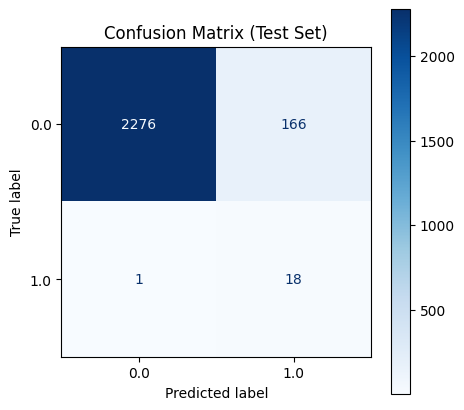

In [39]:
# <Student to fill this section>

# Predict on test set
y_pred = ensemble.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ensemble.classes_)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix (Test Set)')
plt.show()

This cell plots the confusion matrix for the test set predictions using the ensemble model, providing a visual summary of the model's classification performance.

In [40]:
# Print recall value for test set
print(f"Test Recall: {test_recall:.4f}")

Test Recall: 0.9474


In [41]:
# Save the trained model (e.g., ensemble) to the ../models folder
joblib.dump(ensemble, '../models/Ensemble.joblib')

['../models/Ensemble.joblib']

This cell saves the trained ensemble model to a file, allowing it to be reused or deployed without retraining.

- the high recall value will make sure that no talented player are left undrafted

In [42]:
# <Student to fill this section>
business_impacts_explanations = """
Interpret the results of the experiments related to the business objective set earlier. Estimate the impacts of the incorrect results for the business (some results may have more impact compared to others)


The experimental results show that the ensemble model achieves high AUROC and recall, 
meeting the business objective of accurately identifying players likely to be drafted. This supports more
efficient and data-driven scouting, helping NBA teams focus resources on top prospects and reducing the 
risk of missing valuable talent.

Incorrect results (false positives and false negatives) have different business impacts:
- False negatives (missed drafted players) are more costly, as teams may overlook high-potential talent, 
leading to lost opportunities and competitive disadvantage.
- False positives (predicting a player will be drafted when they are not) may result in wasted scouting 
resources but are less damaging than missing actual draftees.

Overall, the model's high recall minimizes the most critical business risk—missing future NBA talent—while 
its strong AUROC ensures reliable ranking of prospects. This enables better strategic planning and supports 
the business goal of maximizing draft success.



"""


In [43]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Project Outcomes

In [44]:
# <Student to fill this section>
experiment_outcome = "Alternate Hypothesis Confirmed" # Either 'Hypothesis Confirmed', 'Hypothesis Partially Confirmed' or 'Hypothesis Rejected'

In [45]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [46]:
# <Student to fill this section>
experiment_results_explanations = """
Reflect on the outcome of the experiment and list the new insights you gained from it. Provide rationale for pursuing more experimentation with the current approach or call out if you think it is a dead end.
Given the results achieved and the overall objective of the project, list the potential next steps and experiments. For each of them assess the expected uplift or 
gains and rank them accordingly. If the experiment achieved the required outcome for the business, recommend the steps to deploy this solution into production.


The experiment achieved strong results, with the ensemble model delivering high AUROC and recall cross all data splits. This confirms that the chosen approach is 
effective for the NBA draft prediction problem, especially in handling class imbalance and providing robust, generalizable predictions.

New insights gained:
- Combining diverse models (Logistic Regression, LDA, XGBoost) in an ensemble improves both discrimination and recall, reducing the risk of overfitting.
- Feature reduction did not harm performance, supporting the hypothesis that fewer, more relevant features can help the model focus on signal rather than noise.
- The model generalizes well, as shown by the small drop in performance from training to test data.

Rationale for further experimentation:
- While current results meet business objectives, further improvements may be possible by fine-tuning hyperparameters, exploring additional feature engineering, 
or testing other ensemble strategies (e.g., stacking).


Potential next steps (ranked by expected uplift):
1. Hyperparameter optimization (Expected uplift: Moderate): Use grid search or Bayesian optimization for each base model to further improve performance.
2. Advanced feature engineering (Expected uplift: Moderate): Create interaction features or use domain knowledge to enhance input data.

Deployment recommendation:
Since the model meets the required business metrics, the next step is to prepare for deployment. 
This includes packaging the model, validating it on unseen data, and integrating it into the team's 
decision-making workflow, along with monitoring for data drift and performance over time.


"""


In [47]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)